<a href="https://colab.research.google.com/github/rfpmaa/uas-ml/blob/main/notebook/UAS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
url = "https://raw.githubusercontent.com/rfpmaa/uas-ml/main/dataset/beasiswa.csv"

df = pd.read_csv(url)

df.head()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Prestasi,Aktif_Organisasi,Status_Rumah,Jenis_Kelamin,Diterima_Beasiswa
0,3.37,2,2000000,3,Internasional,Tidak,Milik Sendiri,P,0
1,3.15,5,4000000,6,Tidak Ada,Ya,Kos/Asrama,P,1
2,3.43,3,1500000,6,Provinsi,Ya,Kontrak,P,1
3,3.73,6,1000000,5,Tidak Ada,Tidak,Milik Sendiri,L,1
4,3.12,2,500000,1,Tidak Ada,Tidak,Milik Sendiri,P,1


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   IPK                  300 non-null    float64
 1   Semester             300 non-null    int64  
 2   Penghasilan_Ortu     300 non-null    int64  
 3   Tanggungan_Keluarga  300 non-null    int64  
 4   Prestasi             300 non-null    object 
 5   Aktif_Organisasi     300 non-null    object 
 6   Status_Rumah         300 non-null    object 
 7   Jenis_Kelamin        300 non-null    object 
 8   Diterima_Beasiswa    300 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 21.2+ KB


In [55]:
df.describe()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Diterima_Beasiswa
count,300.000000,300.000000,3.000000e+02,300.000000,300.000000
mean,3.195400,4.906667,2.065000e+06,3.396667,0.706667
std,0.336704,1.999487,1.283393e+06,1.701658,0.456051
min,2.070000,2.000000,5.000000e+05,1.000000,0.000000
25%,2.960000,3.000000,1.000000e+06,2.000000,0.000000
50%,3.220000,5.000000,1.500000e+06,3.000000,1.000000
75%,3.420000,6.000000,3.000000e+06,5.000000,1.000000
max,4.000000,8.000000,6.000000e+06,6.000000,1.000000


In [56]:
df.dtypes

,0
IPK,float64
Semester,int64
Penghasilan_Ortu,int64
Tanggungan_Keluarga,int64
Prestasi,object
Aktif_Organisasi,object
Status_Rumah,object
Jenis_Kelamin,object
Diterima_Beasiswa,int64


In [57]:
df.isnull().sum()

,0
IPK,0
Semester,0
Penghasilan_Ortu,0
Tanggungan_Keluarga,0
Prestasi,0
Aktif_Organisasi,0
Status_Rumah,0
Jenis_Kelamin,0
Diterima_Beasiswa,0


In [87]:
df["Diterima_Beasiswa"].value_counts()

,count
Diterima_Beasiswa,
1,212
0,88


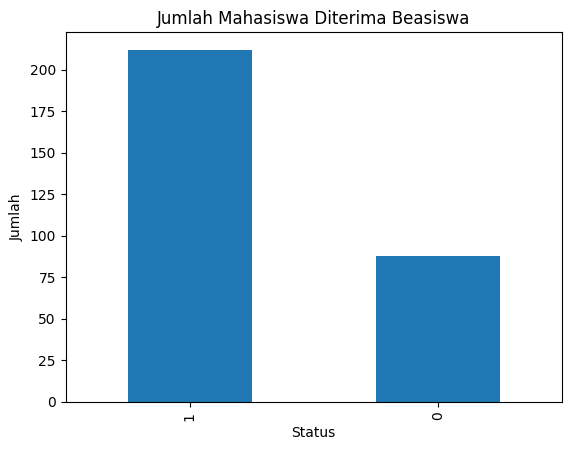

In [88]:
df["Diterima_Beasiswa"].value_counts().plot(kind="bar")

plt.title("Jumlah Mahasiswa Diterima Beasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.show()

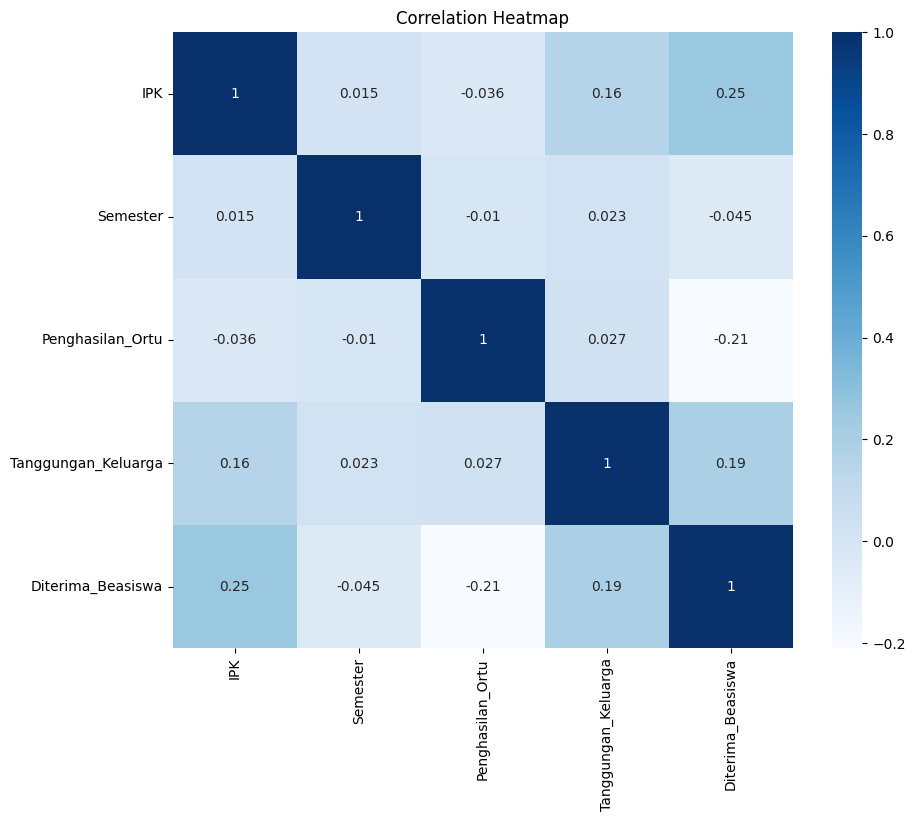

In [89]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [58]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le = LabelEncoder()

categorical_cols = [
    'Prestasi',
    'Aktif_Organisasi',
    'Status_Rumah',
    'Jenis_Kelamin',
    'Diterima_Beasiswa'
]

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Prestasi,Aktif_Organisasi,Status_Rumah,Jenis_Kelamin,Diterima_Beasiswa
0,3.37,2,2000000,3,0,0,3,1,0
1,3.15,5,4000000,6,4,1,1,1,1
2,3.43,3,1500000,6,3,1,0,1,1
3,3.73,6,1000000,5,4,0,3,0,1
4,3.12,2,500000,1,4,0,3,1,1


In [90]:
X = df_encode.drop("Diterima_Beasiswa", axis=1)
y = df_encode["Diterima_Beasiswa"]

print("Jumlah fitur :", X.shape)
print("Jumlah target :", y.shape)

Jumlah fitur : (300, 8)
Jumlah target : (300,)


In [59]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Diterima_Beasiswa', axis=1)
y = df_model['Diterima_Beasiswa']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)

X Train : (240, 8)
X Test  : (60, 8)


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest berhasil dilatih!")

Random Forest berhasil dilatih!


In [61]:
y_pred_rf = rf.predict(X_test)

In [62]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7333333333333333

Classification Report

              precision    recall  f1-score   support

           0       0.62      0.28      0.38        18
           1       0.75      0.93      0.83        42

    accuracy                           0.73        60
   macro avg       0.69      0.60      0.61        60
weighted avg       0.71      0.73      0.70        60



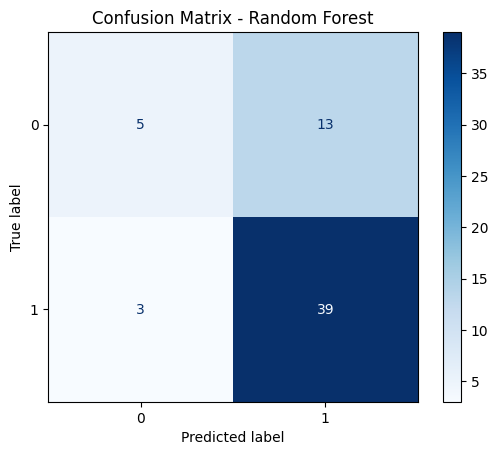

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [64]:
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

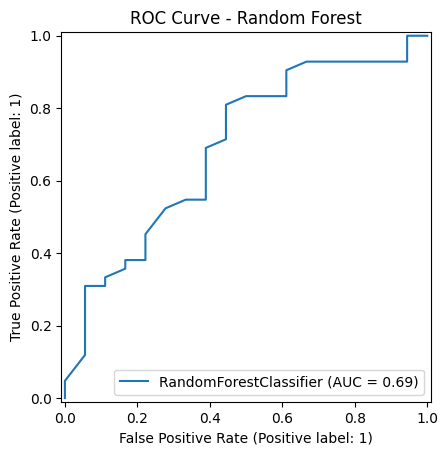

In [65]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

In [66]:
plt.savefig("roc_curve_rf.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

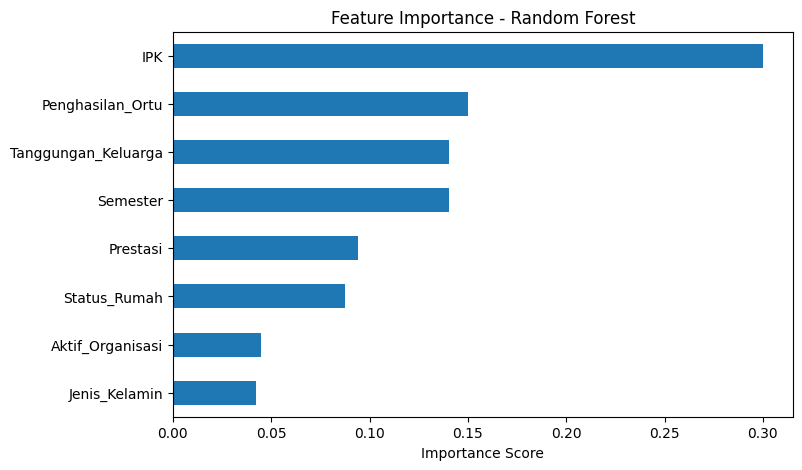

In [67]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importance.plot(kind="barh")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [73]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

print("SVM berhasil dilatih!")

SVM berhasil dilatih!


In [74]:
y_pred_svm = svm.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy SVM :", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm))

Accuracy SVM : 0.7

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.70      1.00      0.82        42

    accuracy                           0.70        60
   macro avg       0.35      0.50      0.41        60
weighted avg       0.49      0.70      0.58        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


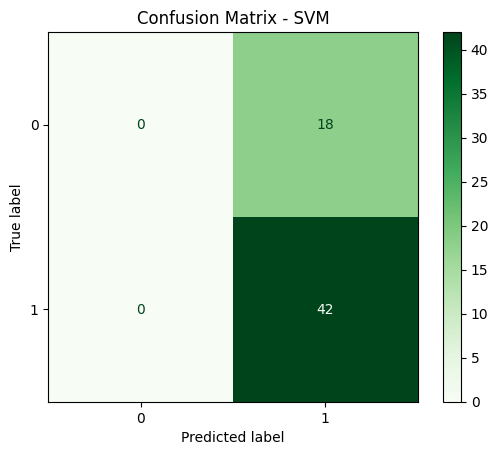

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Confusion Matrix - SVM")
plt.show()

In [77]:
plt.savefig("confusion_matrix_svm.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

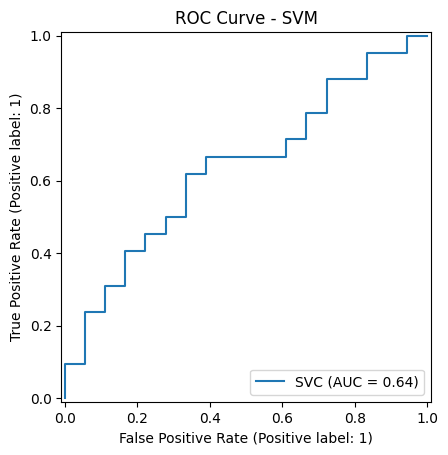

In [79]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test
)

plt.title("ROC Curve - SVM")
plt.show()

In [80]:
plt.savefig("roc_curve_svm.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [81]:
import pandas as pd
from sklearn.metrics import accuracy_score

hasil = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})

hasil

,Model,Accuracy
0,Random Forest,0.733333
1,SVM,0.700000


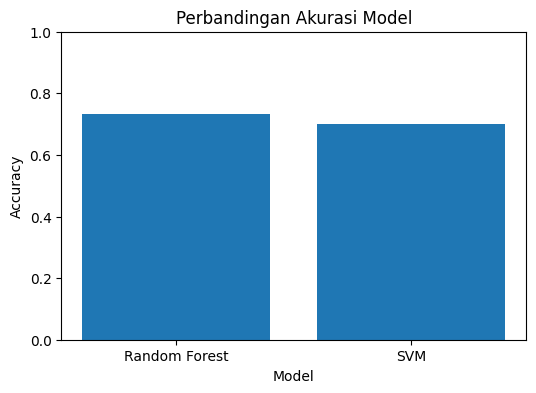

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(hasil['Model'], hasil['Accuracy'])

plt.title('Perbandingan Akurasi Model')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.ylim(0,1)

plt.show()